# SEA single-drift experiment — STUDD with paper parameters

This notebook studies STUDD on a synthetic SEA stream with one abrupt concept drift.

We use the parameter setup described in the STUDD paper as closely as possible within CapyMOA:

- training window size: $$W = 2000$$
- teacher: RF-style ensemble with 100 trees
- student: either RF-style ensemble with 100 trees or Hoeffding Tree
- detector: Page-Hinkley with $$\delta = 0.001$$
- drift signal: teacher-student imitation error

Note: the paper uses scikit-learn Random Forests. In CapyMOA, we approximate this with `AdaptiveRandomForestClassifier(ensemble_size=100)` and disable its internal drift detection/background learner.

In [57]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from capymoa.stream.generator import SEA as CapySEA
from capymoa.stream.drift import DriftStream, Drift
from capymoa.drift.detectors import STUDD, PageHinkley

from helpers import (
    configure_matplotlib,
    rolling_mean,
    add_drift_markers,
    plot_sea_data,
    collect_capymoa_samples,
)

from studd_utils import (
    make_rf,
    make_student,
    collect_instances,
)

configure_matplotlib()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameters

The paper uses $W = 2000$ for most data streams, Random Forests with 100 trees, and Page-Hinkley with $\delta = 0.001$.

Set `STUDENT_TYPE = "rf"` for the paper-like RF/RF case.

Set `STUDENT_TYPE = "ht"` for the RF/HoeffdingTree experiment.

In [58]:
W = 2_000
N_TREES = 100
PH_DELTA = 0.001
SEED = 1

STUDENT_TYPE = "ht"   # choose: "rf" or "ht"

n1 = W
n2 = 10_000
drift_pos = 5_000

CAPYMOA_SEA_THRESHOLDS = {
    1: 8.0,
    2: 9.0,
    3: 7.0,
    4: 9.5,
}

f_old_moa = 4
f_new_moa = 3

theta_old = CAPYMOA_SEA_THRESHOLDS[f_old_moa]
theta_new = CAPYMOA_SEA_THRESHOLDS[f_new_moa]

## Data generation

We generate:

1. A reference dataset from the initial SEA concept.
2. A stream with abrupt drift at index 5000.

The reference data are used to train the teacher.
The stream is then used for online STUDD monitoring.

In [59]:
sea_ref = CapySEA(
    function=f_old_moa,
    instance_random_seed=SEED,
    noise_percentage=0,
    balance_classes=True,
)

reference_instances = collect_instances(sea_ref, n1)

sea_ref_vis = CapySEA(
    function=f_old_moa,
    instance_random_seed=SEED,
    noise_percentage=0,
    balance_classes=True,
)

X_ref, y_ref = collect_capymoa_samples(sea_ref_vis, n1)

drift_stream = DriftStream(stream=[
    CapySEA(
        function=f_old_moa,
        instance_random_seed=SEED + 10,
        noise_percentage=0,
    ),
    Drift(position=drift_pos, width=0),
    CapySEA(
        function=f_new_moa,
        instance_random_seed=SEED + 20,
        noise_percentage=0,
    ),
])

X_stream, y_stream = collect_capymoa_samples(drift_stream, n2)

drift_stream.restart()
schema = drift_stream.get_schema()

print(f"Reference : {X_ref.shape} classes={np.unique(y_ref, return_counts=True)[1]}")
print(f"Stream    : {X_stream.shape} classes={np.unique(y_stream, return_counts=True)[1]}")

Reference : (2000, 3) classes=[1000 1000]
Stream    : (10000, 3) classes=[3563 6437]


## Reference and stream data

The SEA decision boundary depends on $x_0 + x_1$.

The plot shows the original concept, the post-drift concept, and the true drift position.

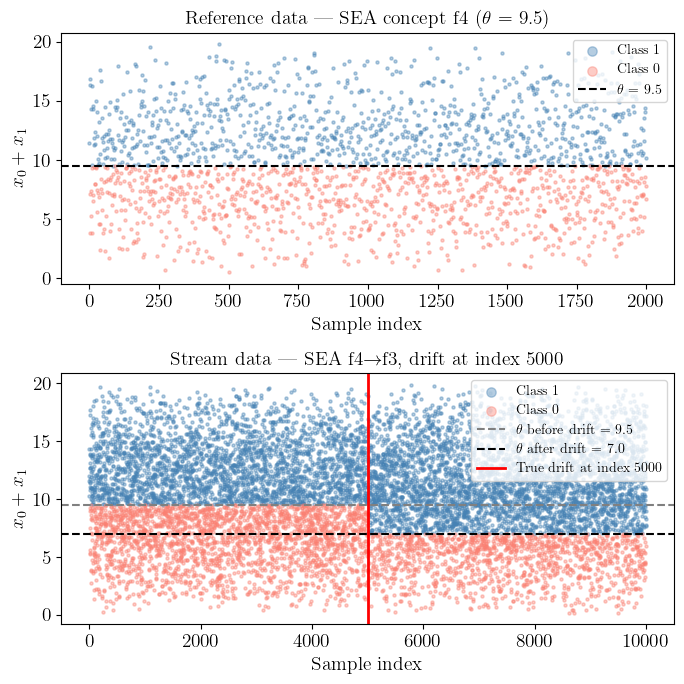

In [60]:
fig, axes = plt.subplots(2, 1, figsize=(7, 7))

plot_sea_data(
    axes,
    X_ref,
    y_ref,
    X_stream,
    y_stream,
    theta_old,
    theta_new,
    f_old_moa,
    f_new_moa,
    drift_pos,
)

plt.tight_layout()
plt.show()

## Teacher training

The teacher is trained offline on the reference data.

In the paper this is a Random Forest with 100 trees. Here we use a CapyMOA RF-style ensemble with 100 trees and disabled internal drift adaptation.

In [61]:
teacher = make_rf(
    schema=schema,
    seed=SEED,
    n_trees=N_TREES,
)

for instance in reference_instances:
    teacher.train(instance)

print(f"Teacher trained on {len(reference_instances)} reference instances.")
print(f"Teacher: RF-style CapyMOA ARF, ensemble_size={N_TREES}")

Teacher trained on 2000 reference instances.
Teacher: RF-style CapyMOA ARF, ensemble_size=100


## STUDD detector

STUDD compares teacher predictions with student predictions.

The detector receives the teacher-student disagreement (imitation error):

$$
\hat{y}_T \ne \hat{y}_S
$$

The base detector is Page-Hinkley with $\delta = 0.001$.

The student is selected by `STUDENT_TYPE`.

In [62]:
student = make_student(
    schema=schema,
    student_type=STUDENT_TYPE,
    seed=SEED + 1,
    n_trees=N_TREES,
)

studd = STUDD(
    student=student,
    min_n_instances=W,
    detector=PageHinkley(delta=PH_DELTA),
)

print(f"Student type: {STUDENT_TYPE}")
print(f"STUDD min_n_instances: {W}")
print(f"Detector: Page-Hinkley(delta={PH_DELTA})")

Student type: ht
STUDD min_n_instances: 2000
Detector: Page-Hinkley(delta=0.001)


## Online stream monitoring

For each stream instance:

1. The teacher predicts a label
2. The student predicts a label
3. We record the teacher-student imitation error
4. STUDD receives the instance and the teacher prediction
5. If Page-Hinkley signals change, we store the detected drift point

In [63]:
studd_drift_points = []

teacher_preds = []
true_labels = []
teacher_correct = []

i = 0

while drift_stream.has_more_instances() and i < n2:
    instance = drift_stream.next_instance()

    teacher_pred = teacher.predict(instance)

    if teacher_pred is None:
        i += 1
        continue

    studd.add_element(instance, teacher_pred)

    teacher_preds.append(teacher_pred)
    true_labels.append(instance.y_index)
    teacher_correct.append(float(teacher_pred == instance.y_index))

    if studd.detected_change():
        studd_drift_points.append(i)

    i += 1

teacher_preds = np.array(teacher_preds)
true_labels = np.array(true_labels)
teacher_correct = np.array(teacher_correct, dtype=float)

# CapyMOA STUDD stores agreement internally:
# 1 = agree, 0 = disagree
agreement = np.array(studd.data, dtype=float)
agreement_offset = W + studd.min_n_instances
agreement_idx = np.arange(len(agreement)) + agreement_offset

# Imitation error / disagreement:
# 1 = disagree, 0 = agree
disagreement = 1 - agreement

print(f"Total STUDD detections : {len(studd_drift_points)}")
print(f"Detections             : {studd_drift_points[:20]}")

if studd_drift_points:
    delay = studd_drift_points[0] - drift_pos
    print(f"First detected at {studd_drift_points[0]} (delay = {delay:+d})")
else:
    print("No drift detected.")

print(f"Agreement values stored by STUDD: {len(agreement)}")
print(f"Agreement starts at stream index: {agreement_offset}")

Total STUDD detections : 2
Detections             : [6594, 9427]
First detected at 6594 (delay = +1594)
Agreement values stored by STUDD: 7986
Agreement starts at stream index: 4000


## Detection summary

We report:

- Teacher classification accuracy before and after the true drift
- Mean teacher–student disagreement (imitation error)
- Number and location of drift alarms produced by STUDD

In [64]:
idx = np.arange(len(teacher_correct))

pre_acc_mask = idx < drift_pos
post_acc_mask = idx >= drift_pos

pre_acc = np.nanmean(teacher_correct[pre_acc_mask])
post_acc = np.nanmean(teacher_correct[post_acc_mask])

pre_dis = disagreement[agreement_idx < drift_pos]
post_dis = disagreement[agreement_idx >= drift_pos]

mean_pre_dis = pre_dis.mean() if len(pre_dis) else float("nan")
mean_post_dis = post_dis.mean() if len(post_dis) else float("nan")
mean_dis = disagreement.mean() if len(disagreement) else float("nan")

print(f"Student type: {STUDENT_TYPE}")
print(f"Teacher accuracy before drift: {100 * pre_acc:.2f}%")
print(f"Teacher accuracy after drift : {100 * post_acc:.2f}%")
print(f"Mean disagreement overall    : {mean_dis:.3f}")
print(f"Mean disagreement before drift: {mean_pre_dis:.3f}")
print(f"Mean disagreement after drift : {mean_post_dis:.3f}")

Student type: ht
Teacher accuracy before drift: 98.60%
Teacher accuracy after drift : 80.10%
Mean disagreement overall    : 0.628
Mean disagreement before drift: 0.651
Mean disagreement after drift : 0.625


## Detection plots

The following plots show:

1. The raw teacher–student disagreement signal.
2. A rolling average of disagreement.
3. The rolling classification accuracy of the teacher.

The vertical green line indicates the true drift position.
Red lines correspond to drift alarms generated by STUDD.

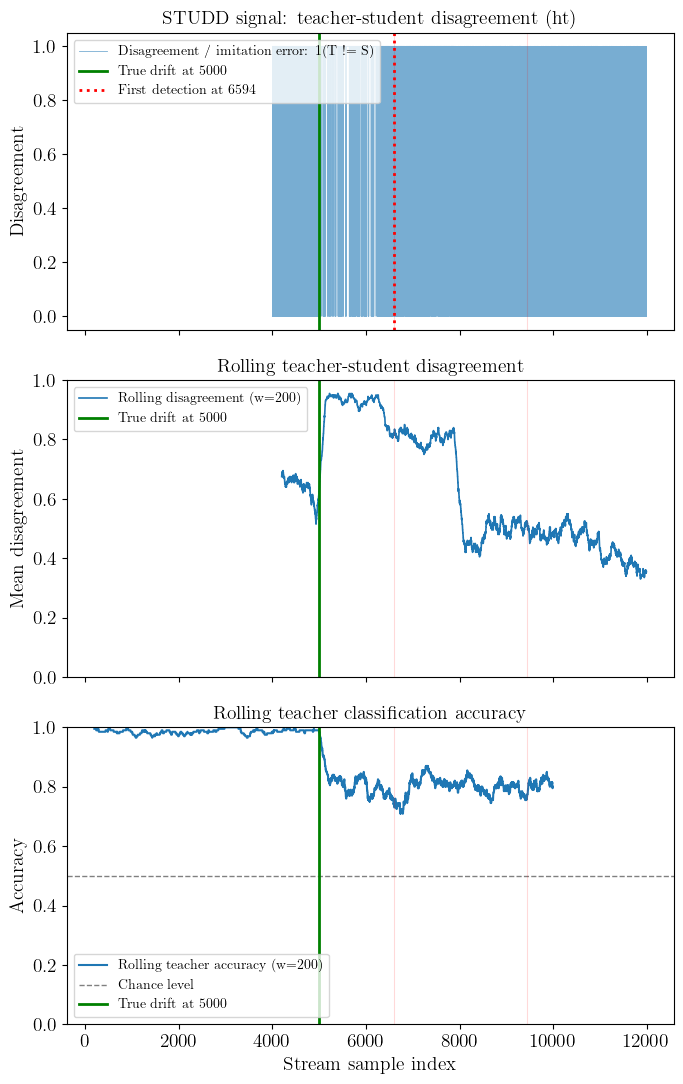

In [65]:
window = 200

rolling_dis, rolling_dis_idx_rel = rolling_mean(
    disagreement,
    window,
)
rolling_dis_idx = rolling_dis_idx_rel + agreement_offset

rolling_acc, rolling_acc_idx = rolling_mean(
    teacher_correct,
    window,
)

fig, axes = plt.subplots(3, 1, figsize=(7, 11), sharex=True)

ax = axes[0]
ax.plot(
    agreement_idx,
    disagreement,
    linewidth=0.6,
    alpha=0.6,
    label="Disagreement / imitation error: 1(T != S)",
)
add_drift_markers(
    ax,
    drift_pos,
    studd_drift_points,
    first_label=f"First detection at {studd_drift_points[0]}" if studd_drift_points else None,
)
ax.set_title(f"STUDD signal: teacher-student disagreement ({STUDENT_TYPE})")
ax.set_ylabel("Disagreement")
ax.legend(loc="upper left")

ax = axes[1]
ax.plot(
    rolling_dis_idx,
    rolling_dis,
    linewidth=1.2,
    label=f"Rolling disagreement (w={window})",
)
add_drift_markers(ax, drift_pos, studd_drift_points)
ax.set_ylim(0, 1)
ax.set_title("Rolling teacher-student disagreement")
ax.set_ylabel("Mean disagreement")
ax.legend(loc="upper left")

ax = axes[2]
ax.plot(
    rolling_acc_idx,
    rolling_acc,
    linewidth=1.5,
    label=f"Rolling teacher accuracy (w={window})",
)
ax.axhline(
    0.5,
    color="gray",
    linestyle="--",
    linewidth=1.0,
    label="Chance level",
)
add_drift_markers(ax, drift_pos, studd_drift_points)
ax.set_ylim(0, 1)
ax.set_title("Rolling teacher classification accuracy")
ax.set_xlabel("Stream sample index")
ax.set_ylabel("Accuracy")
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()

## Disagreement before and after drift

To quantify the effect of concept drift on the STUDD signal, we compare the distribution of teacher–student disagreement before and after the true drift location.

If STUDD behaves as expected, disagreement should increase after drift.

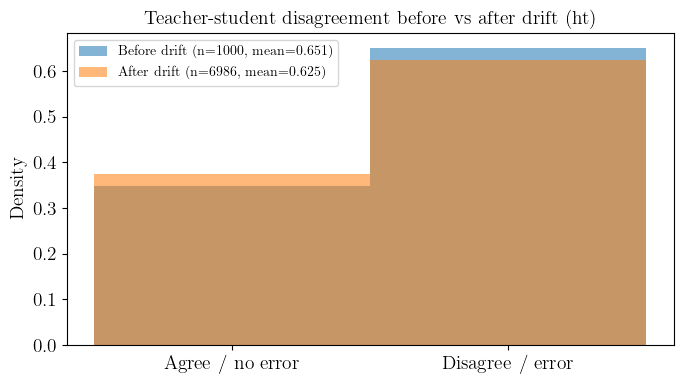

In [66]:
pre_dis = disagreement[agreement_idx < drift_pos]
post_dis = disagreement[agreement_idx >= drift_pos]

mean_pre = pre_dis.mean() if len(pre_dis) else float("nan")
mean_post = post_dis.mean() if len(post_dis) else float("nan")

fig, ax = plt.subplots(figsize=(7, 4))

bins = [-0.5, 0.5, 1.5]

ax.hist(
    pre_dis,
    bins=bins,
    density=True,
    alpha=0.55,
    label=f"Before drift (n={len(pre_dis)}, mean={mean_pre:.3f})",
)

ax.hist(
    post_dis,
    bins=bins,
    density=True,
    alpha=0.55,
    label=f"After drift (n={len(post_dis)}, mean={mean_post:.3f})",
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Agree / no error", "Disagree / error"])
ax.set_ylabel("Density")
ax.set_title(f"Teacher-student disagreement before vs after drift ({STUDENT_TYPE})")
ax.legend()

plt.tight_layout()
plt.show()

## Local analysis around the true drift and drift alarms

The global disagreement averages do not clearly reveal the concept change.

However, when focusing on the local region (1000 points) around the true drift point, the teacher-student disagreement increases substantially:

- disagreement before drift: 0.651
- disagreement after drift: 0.935
- delta: +0.284

This result indicates that the teacher-student relationship changes significantly immediately after the concept drift. The disagreement signal reacts directly to the distribution shift, even before the detector raises an alarm.

We also examined the local behaviour around the detected STUDD alarms.

For the first alarm:

- disagreement before alarm: 0.897
- disagreement after alarm: 0.802
- delta: -0.095

For the second alarm:

- disagreement before alarm: 0.510
- disagreement after alarm: 0.487
- delta: -0.023

Interestingly, disagreement does not increase after the alarms. Instead, it remains high or slightly decreases. 
Τhe disagreement increase is observed immediately after the true drift. The alarms therefore correspond to the confirmation of an already established change in the teacher-student relationship.

In [67]:
LOCAL_DRIFT_WINDOW = 1000

before_mask = (
    (agreement_idx >= drift_pos - LOCAL_DRIFT_WINDOW)
    &
    (agreement_idx < drift_pos)
)

after_mask = (
    (agreement_idx >= drift_pos)
    &
    (agreement_idx < drift_pos + LOCAL_DRIFT_WINDOW)
)

before_disagreement = disagreement[before_mask]
after_disagreement = disagreement[after_mask]

print(
    "Before true drift disagreement:",
    before_disagreement.mean()
)

print(
    "After true drift disagreement:",
    after_disagreement.mean()
)

print(
    "Delta:",
    after_disagreement.mean()
    - before_disagreement.mean()
)

Before true drift disagreement: 0.651
After true drift disagreement: 0.935
Delta: 0.28400000000000003


In [68]:
LOCAL_DRIFT_WINDOW = 1000

before_mask = (
    (agreement_idx >= studd_drift_points[0] - LOCAL_DRIFT_WINDOW)
    &
    (agreement_idx < studd_drift_points[0])
)

after_mask = (
    (agreement_idx >= studd_drift_points[0])
    &
    (agreement_idx < studd_drift_points[0] + LOCAL_DRIFT_WINDOW)
)

before_disagreement = disagreement[before_mask]
after_disagreement = disagreement[after_mask]

print(
    "Before drift 1 disagreement:",
    before_disagreement.mean()
)

print(
    "After drift 1 disagreement:",
    after_disagreement.mean()
)

print(
    "Delta:",
    after_disagreement.mean()
    - before_disagreement.mean()
)

Before drift 1 disagreement: 0.897
After drift 1 disagreement: 0.802
Delta: -0.09499999999999997


In [69]:
LOCAL_DRIFT_WINDOW = 1000

before_mask = (
    (agreement_idx >= studd_drift_points[1] - LOCAL_DRIFT_WINDOW)
    &
    (agreement_idx < studd_drift_points[1])
)

after_mask = (
    (agreement_idx >= studd_drift_points[1])
    &
    (agreement_idx < studd_drift_points[1] + LOCAL_DRIFT_WINDOW)
)

before_disagreement = disagreement[before_mask]
after_disagreement = disagreement[after_mask]

print(
    "Before drift 2 disagreement:",
    before_disagreement.mean()
)

print(
    "After drift 2 disagreement:",
    after_disagreement.mean()
)

print(
    "Delta:",
    after_disagreement.mean()
    - before_disagreement.mean()
)

Before drift 2 disagreement: 0.51
After drift 2 disagreement: 0.487
Delta: -0.02300000000000002


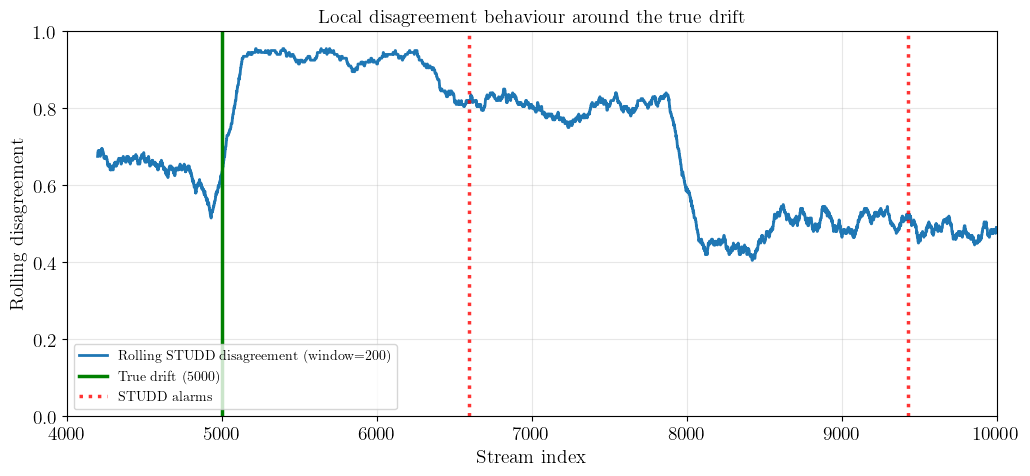

In [70]:
DRIFT_ZOOM_START = 4000
DRIFT_ZOOM_END = 10000
ROLLING_WINDOW = 200

rolling_disagreement, _ = rolling_mean(
    disagreement,
    ROLLING_WINDOW,
)

rolling_disagreement_idx = agreement_idx[
    ROLLING_WINDOW - 1:
]

zoom_mask = (
    (rolling_disagreement_idx >= DRIFT_ZOOM_START)
    &
    (rolling_disagreement_idx <= DRIFT_ZOOM_END)
)

plt.figure(figsize=(12, 5))

plt.plot(
    rolling_disagreement_idx[zoom_mask],
    rolling_disagreement[zoom_mask],
    linewidth=2,
    label=f"Rolling STUDD disagreement (window={ROLLING_WINDOW})",
)

plt.axvline(
    drift_pos,
    color="green",
    linestyle="-",
    linewidth=2.5,
    label=f"True drift ({drift_pos})",
)

for i, alarm_t in enumerate(studd_drift_points):

    if DRIFT_ZOOM_START <= alarm_t <= DRIFT_ZOOM_END:

        plt.axvline(
            alarm_t,
            color="red",
            linestyle=":",
            linewidth=2.5,
            alpha=0.8,
            label="STUDD alarms" if i == 0 else None,
        )

plt.title(
    "Local disagreement behaviour around the true drift"
)
plt.xlabel("Stream index")
plt.ylabel("Rolling disagreement")
plt.xlim(
    DRIFT_ZOOM_START,
    DRIFT_ZOOM_END,
)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()